In [4]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "prophet==1.3.0" "statsmodels==0.14.6"

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from prophet import Prophet
import warnings; warnings.filterwarnings("ignore")
import cmdstanpy; cmdstanpy.utils.get_logger().disabled = True   # 적합 때마다 찍히는 진행 로그를 끈다
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다
SEED = 42        # Prophet 의 구간은 시뮬레이션이라 시드를 고정해야 본문 숫자가 재현된다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [5]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

표 1 · 예측 원점 5개의 168시간 RMSE (대)
  예측 원점        계절 나이브 168   Prophet 기본 구성
  10월 19일 23시            306.52              366.45
  10월 26일 23시            418.18              410.32
  11월  2일 23시            457.07              475.13
  11월  9일 23시            430.72              343.56
  11월 16일 23시            205.25              310.38
  평균                      363.55              381.17


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching Malgun Gothic:style=normal:variant=normal:weight=regular:stretch=normal:size=11.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\pyostry\\.conda\\envs\\myenv312\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizFiveSymReg.ttf', index=0, name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\pyostry\\.conda\\envs\\myenv312\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', index=0, name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\

표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)
  잠재적 변화점          25
  연간 계절성 포함 적합  0
  연간 계절성 제외 적합  7


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\ntailub.ttf', index=0, name='Microsoft New Tai Lue', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\cambriai.ttf', index=0, name='Cambria', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\calibril.ttf', index=0, name='Calibri', style='normal', variant='normal', weight=300, stretch='normal', size='scalable')) = 10.145
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\calibril.ttf', index=0, name='Calibri Light', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\hpsimplifiedjpan-light.ttf', index=0, name='

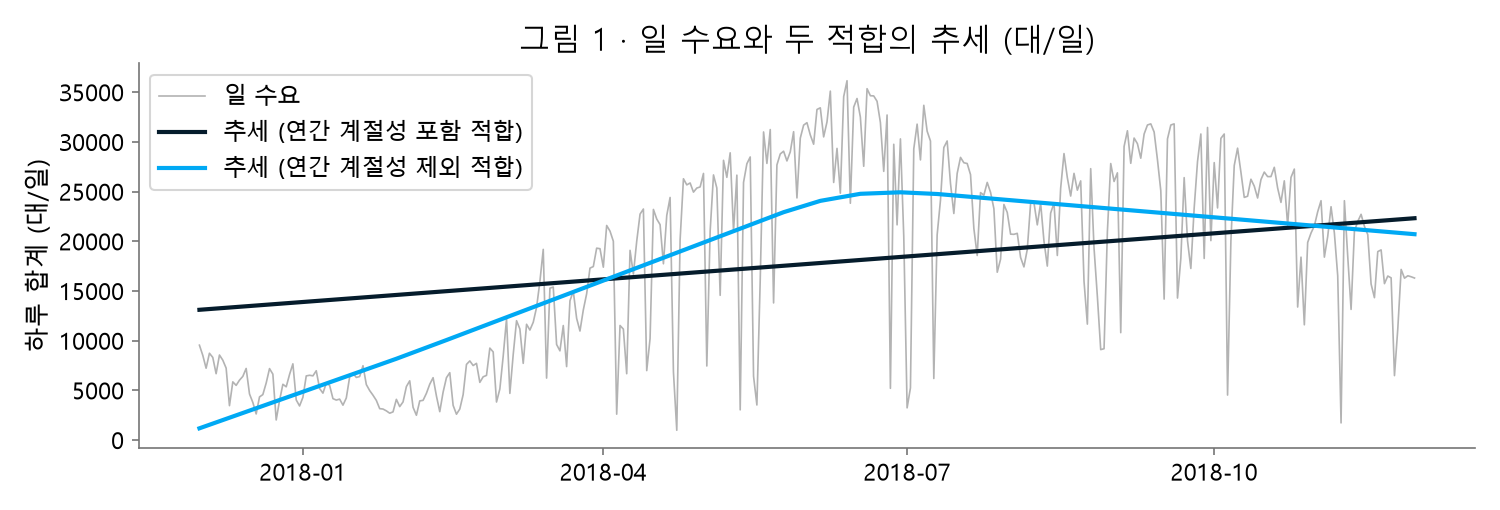

In [19]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1 · 표 2 · 그림 1 을 만듭니다. Prophet 을 7번 적합해 30초 안팎 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

# 표 1: 금요일 23시 예측 원점 5개마다 9월 1일부터 원점까지로 재적합해 168시간을 한 번에 예측한다
origins = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")
origin_rmse = []                          # (원점, 계절 나이브 168, Prophet 기본 구성)
for o in origins:
    fit_part = df.loc["2018-09-01 00:00":o, "demand"]
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                holidays=holidays_one, uncertainty_samples=0)          # 구간 없이 예측값만 낸다
    m.fit(pd.DataFrame({"ds": fit_part.index, "y": fit_part.values}))
    y_week = df.loc[week, "demand"]
    origin_rmse.append((o, rmse(y_week, df["demand"].shift(168).loc[week]),    # 1주일 전 같은 시각 값
                        rmse(y_week, m.predict(pd.DataFrame({"ds": week}))["yhat"])))
sn5_mean = float(np.mean([r[1] for r in origin_rmse]))
p5_mean = float(np.mean([r[2] for r in origin_rmse]))
print("표 1 · 예측 원점 5개의 168시간 RMSE (대)")
print("  예측 원점        계절 나이브 168   Prophet 기본 구성")
for o, sn, pr in origin_rmse:
    print(f"  {o.month:>2}월 {o.day:>2}일 23시   {sn:15.2f}   {pr:17.2f}")
print(f"  평균             {sn5_mean:15.2f}   {p5_mean:17.2f}")

# 표 2 · 그림 1: 일 수요 365일에 연간 계절성을 포함한 적합과 제외한 적합, 잠재적 변화점의 성장률 변화량을 센다
_sum = df["demand"].resample("D").sum()                     # 보정 수요의 하루 합계
daily = pd.DataFrame({"ds": _sum.index, "y": _sum.values})
cp_count, daily_trend = {}, {}
for yearly in (True, False):
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=True, daily_seasonality=False,
                uncertainty_samples=0)                      # 일 수요에는 하루 안의 주기가 없다
    m.fit(daily)
    delta = m.params["delta"].mean(axis=0)                  # 잠재적 변화점마다 성장률 변화량
    cp_count[yearly] = int((np.abs(delta) > 0.01).sum())
    daily_trend[yearly] = m.predict(daily)["trend"].values
print("표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)")
print(f"  잠재적 변화점          {len(m.changepoints)}")
print(f"  연간 계절성 포함 적합  {cp_count[True]}")
print(f"  연간 계절성 제외 적합  {cp_count[False]}")

fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.plot(daily["ds"], daily["y"], color=COL["연회색"], lw=0.8, label="일 수요")
ax.plot(daily["ds"], daily_trend[True], color=COL["남색"], lw=2.0, label="추세 (연간 계절성 포함 적합)")
ax.plot(daily["ds"], daily_trend[False], color=COL["하늘색"], lw=2.0, label="추세 (연간 계절성 제외 적합)")
ax.set_title("그림 1 · 일 수요와 두 적합의 추세 (대/일)")
ax.set_ylabel("하루 합계 (대/일)")
datefmt(ax, "%Y-%m", 7)
ax.legend(loc="upper left")
plt.show()

# 80% 구간이 한쪽으로만 벗어났다면 무엇부터 고치나
예를 들어 80% 예측구간이 검증 100시각 가운데 60시각만 담았고, 벗어난 40시각이 모두 구간 아래였다고 합시다.

B. 예측선이 실측보다 높게 치우쳤으니 모형 구성부터 고친다

벗어난 방향이 한쪽인지 양쪽인지를 먼저 봅니다. 40시각이 모두 하한 아래라면 실측이 예측선보다 낮은 쪽으로 몰린 것입니다. 구간은 예측선을 가운데 두고 만들어지므로, 예측선이 위로 치우쳤다는 뜻입니다. 명목 포함률을 0.95 로 높이면 구간은 길어지지만 예측선의 치우침은 바뀌지 않아, 필요 이상으로 넓은 구간이 됩니다. 절반을 넘게 담았으니 괜찮다는 셋째 보기는 명목 80% 와 비교하지 않은 읽기입니다. 그래서 요일별 하루 모양이나 휴일처럼 예측선을 움직이는 구성을 먼저 바꾸고, 같은 검증 구간에서 실제 포함률을 다시 계산합니다. 보고서에는 「80% 예측구간, 실제 포함률 60%, 벗어난 40시각 모두 아래」처럼 세 가지를 함께 적습니다. 위아래로 고르게 벗어났을 때만 명목 포함률을 높이는 쪽을 검토합니다.

핵심 키워드: 벗어난 방향, 예측선의 치우침, 명목 포함률과 실제 포함률을 함께 보고

# 금요일 23시에 다음 168시간을 예측할 때 더할 수 있는 열은
예를 들어 11월 16일(금) 23시에 다음 168시간의 수요를 예측하며, 아래 열 가운데 하나를 add_regressor 로 더하려 합니다. 학습 구간에서는 세 열 모두 수요와 상관이 높았다고 합시다.

A. 시간별 기온: 기상청 예보로 다음 7일 값을 채울 수 있다

외생 변수는 예측 원점에서 예측 기간의 값을 채울 수 있어야 씁니다. 11월 16일 23시에는 17일 0시부터 23일 23시까지의 반납 건수와 앱 접속자 수가 아직 없습니다. 기온은 기상청 예보로 그 168시간을 채울 수 있습니다. 반납 건수를 고른 둘째 보기는 상관의 크기로 고른 것이고, 과거 구간에만 값이 있어 예측 표를 채우지 못합니다. 앱 접속자 수를 고른 셋째 보기는 한두 시간 먼저 움직여도 168시간 뒤까지의 값은 모른다는 점을 놓쳤습니다. 기온을 더할 때도 검증에서는 실측을, 운영에서는 예보를 대입하게 되므로 검증 RMSE 옆에 「실측 날씨를 대입한 사후 예측」이라고 적습니다. 그래서 열을 고를 때는 「11월 16일 23시에 이 열의 다음 168시간 값을 어디서 가져오나」부터 한 문장으로 적어 봅니다.

핵심 키워드: 예측 원점에 채울 수 있는 값, 상관의 크기는 기준이 아니다, 사후 예측

# 원점 5개 평가표로 내리는 투입 판단
「오늘의 준비」 셀을 실행하면 나오는 「표 1 · 예측 원점 5개의 168시간 RMSE (대)」를 봅니다. Prophet 기본 구성을 운영 예측에 투입할까요?

C. 투입하지 않는다. 원점 5개 평균 RMSE 가 베이스라인보다 크다

투입 기준은 한 주의 순위가 아니라 원점 5개 평균을 베이스라인과 비교한 값입니다. 표 1 의 평균 행에서 계절 나이브 168 은 363.55대이고, Prophet 기본 구성은 약 381대로 더 큽니다. 원점별로 보면 11월 9일은 Prophet 이 베이스라인 430.72대보다 20% 가량 작았습니다. 반대로 10월 19일과 11월 16일은 베이스라인이 훨씬 작았습니다. 첫 보기는 이긴 한 주만 골라 읽은 것입니다. 둘째 보기는 원점마다 순위가 바뀌기 때문에 평균으로 정한다는 점을 거꾸로 읽었습니다. 그래서 이번 주 운영 예측은 계절 나이브 168(df["demand"].shift(168))로 냅니다. 보고서에는 원점 5개별 RMSE 와 평균을 표 1 그대로 함께 적습니다. 조건부 계절성처럼 새 구성을 시험할 때도 같은 원점 5개로 채점해 표 1 에 한 열씩 더합니다.

핵심 키워드: 원점 5개 평균이 투입 기준, 한 주의 순위는 원점마다 바뀐다, 운영 예측은 베이스라인


# 연간 계절성을 제외하자 생긴 꺾임을 보고할 때
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)」와 「그림 1 · 일 수요와 두 적합의 추세 (대/일)」를 함께 봅니다. 꺾임은 추세 기울기가 바뀐 곳입니다. 운영팀장에게 보고할 때 맞는 읽기는?

B. 꺾임은 모형에 포함한 성분에 따라 달라지니 개수와 함께 성분 구성을 적는다

두 적합에서 달라진 것은 연간 계절성 하나라는 점이 열쇠입니다. 표 2 에서 잠재적 변화점은 25곳으로 같은데, 변화량이 큰 변화점은 연간 계절성을 포함하면 0곳, 제외하면 7곳입니다. 그림 1 에서 연간 계절성을 포함한 적합의 추세는 1년 내내 거의 직선으로 오르고, 제외한 적합의 추세는 5～7월에 크게 꺾입니다. 첫 보기는 데이터가 한 행도 바뀌지 않았는데 꺾임이 드러났다고 읽은 것입니다. 실제로는 연간 계절성이 설명하던 여름 고점과 겨울 저점이 추세로 옮겨 갔습니다. 셋째 보기는 지나치게 물러선 읽기로, 구성을 함께 적으면 개수도 근거가 됩니다. 이번 주 보고에는 「연간·주간 계절성을 포함한 구성(변화점 설정은 Prophet 기본값)에서 변화량이 큰 변화점 0곳, 추세는 1년 내내 증가」처럼 구성과 결과를 한 문장에 적습니다. 자료가 1년뿐이라 계절과 성장을 나누려면 2년 이상이 필요하다는 점도 한 문장 함께 적습니다.

핵심 키워드: 같은 데이터 다른 성분 구성, 변화점은 사건이 아니다, 개수에는 구성을 함께 적는다

In [20]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

print(f"학습 {len(train):,}시간  {train.index[0]:%m-%d %H시} ~ {train.index[-1]:%m-%d %H시}")
print(f"검증 {len(valid):,}시간  {valid.index[0]:%m-%d %H시} ~ {valid.index[-1]:%m-%d %H시}")
print(f"휴일 데이터프레임 {len(holidays_one)}행, 열 {list(holidays_one.columns)}")
print(f"시드 SEED = {SEED}: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임)"
      " · SEED (시드) · rmse(a, b)")

학습 1,848시간  09-01 00시 ~ 11-16 23시
검증 168시간  11-17 00시 ~ 11-23 23시
휴일 데이터프레임 18행, 열 ['holiday', 'ds']
시드 SEED = 42: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다
쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임) · SEED (시드) · rmse(a, b)


명목 포함률: 80%
실제 포함률: 89.88%
대조용 — 아래로 벗어난 시각 수: 12, 위로 벗어난 시각 수: 5


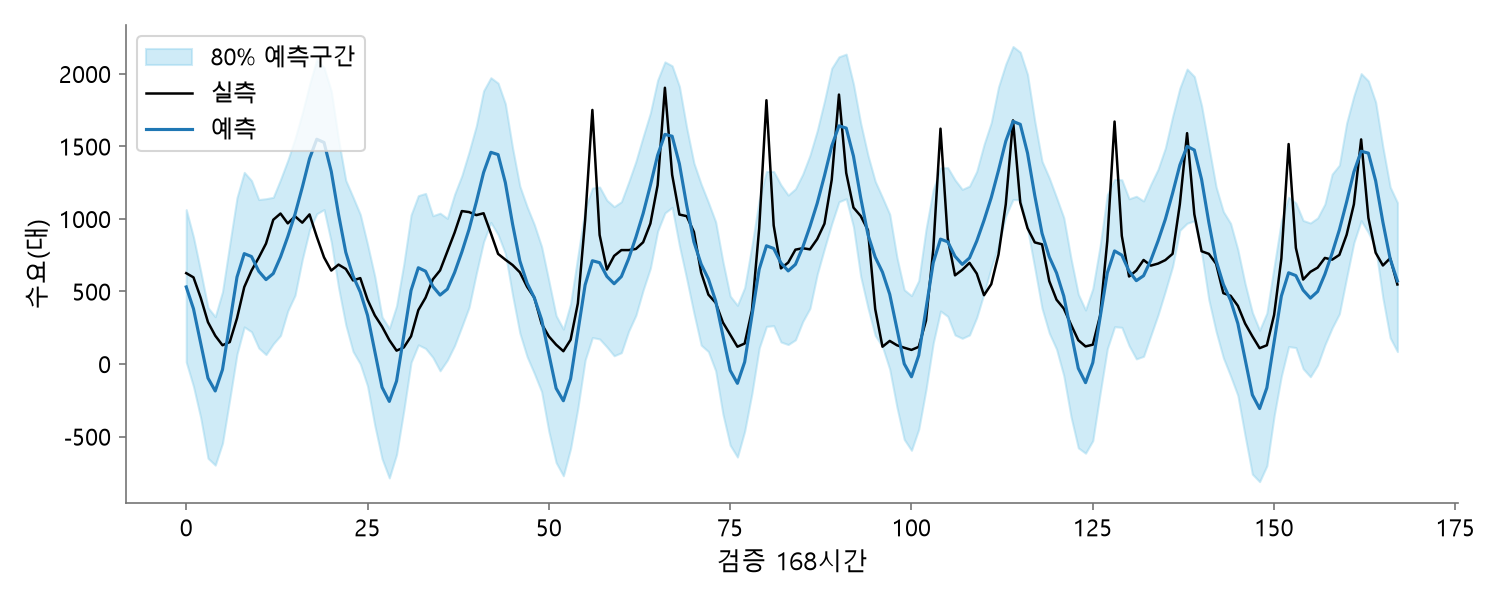

In [21]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
아래 출력물 나오도록 코드 작성해줘
1. 명목 포함률: 단위 %, 정수, 코드에 숫자로 적지 않고 적합한 모형의 interval_width에서 읽음
2. 실제 포함률: 단위 %, 소수 둘째 자리, 실측이 yhat_lower 이상 yhat_upper 이하인 시각의 비율
3. 대조용 한행: 구간 아래로 벗어난 시각 수와 위로 벗어난 시각 수 채점하지 않음
4. 그래프
가로축: '검증 168시간'
세로축: '수요(대)'
실측선, 예측선 2개와 연게 칠한 80% 예측구간
"""
# --- 여기부터 AI 코드 ---
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
            holidays=holidays_one, interval_width=0.8, uncertainty_samples=1000)
m.fit(pd.DataFrame({"ds": train.index, "y": train["demand"].values}))

np.random.seed(SEED)   # 표본 경로 추출 직전에 시드 고정
fcst = m.predict(pd.DataFrame({"ds": valid.index}))

actual = valid["demand"].values
lower = fcst["yhat_lower"].values
upper = fcst["yhat_upper"].values

nominal_pct = round(m.interval_width * 100)
inside = (actual >= lower) & (actual <= upper)
actual_pct = inside.mean() * 100
n_below = int((actual < lower).sum())
n_above = int((actual > upper).sum())

print(f"명목 포함률: {nominal_pct}%")
print(f"실제 포함률: {actual_pct:.2f}%")
print(f"대조용 — 아래로 벗어난 시각 수: {n_below}, 위로 벗어난 시각 수: {n_above}")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(168)
ax.fill_between(x, lower, upper, color="skyblue", alpha=0.4, label=f"{nominal_pct}% 예측구간")
ax.plot(x, actual, color="black", lw=1.2, label="실측")
ax.plot(x, fcst["yhat"].values, color="tab:blue", lw=1.5, label="예측")
ax.set_xlabel("검증 168시간")
ax.set_ylabel("수요(대)")
ax.legend(loc="upper left")
plt.show()

In [22]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표
REGS = ["rain", "temp"]                                    # 더할 외생 변수 두 열

#  비교할 두 RMSE 를 이 셀에서 다시 만든다. 날씨 없는 Prophet 기본 구성과 1주일 전 같은 시각 값
m_base = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                 holidays=holidays_one, uncertainty_samples=0)
m_base.fit(pd.DataFrame({"ds": train.index, "y": train["demand"].values}))
BASE_RMSE = rmse(valid["demand"], m_base.predict(pd.DataFrame({"ds": valid.index}))["yhat"])
SNAIVE_RMSE = rmse(valid["demand"], df["demand"].shift(168).loc[valid.index])

q05 = train["temp"].quantile(0.05)                        # 학습 기온을 낮은 쪽부터 정렬한 5% 지점
print(f"학습 {len(train):,}시간 · 검증 {len(valid)}시간 · 휴일 데이터프레임 {len(holidays_one)}행")
print(f"기온 평균: 학습 {train['temp'].mean():.2f}도, 검증 {valid['temp'].mean():.2f}도")
print(f"검증 168시간 가운데 학습 기온의 5% 지점({q05:.1f}도)보다 추운 시각: "
      f"{int((valid['temp'] < q05).sum())}시간")
print(f"비 온 시각: 학습 {int((train['rain'] > 0).sum())}시간, 검증 {int((valid['rain'] > 0).sum())}시간")
print(f"비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 {BASE_RMSE:.2f}대, 계절 나이브 168 {SNAIVE_RMSE:.2f}대")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열)"
      " · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)")

학습 1,848시간 · 검증 168시간 · 휴일 데이터프레임 18행
기온 평균: 학습 15.83도, 검증 4.91도
검증 168시간 가운데 학습 기온의 5% 지점(6.2도)보다 추운 시각: 101시간
비 온 시각: 학습 95시간, 검증 2시간
비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 310.38대, 계절 나이브 168 205.25대
쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열) · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)


날씨를 더한 검증 168시간 RMSE = 342.15 대
기온 계수 = 40.31 대/도
판단: 이번 검증 구간은 날씨를 더해도 RMSE가 줄지 않았다 — 운영에서는 기상청 예보값으로 채우되 효과를 재검증한다


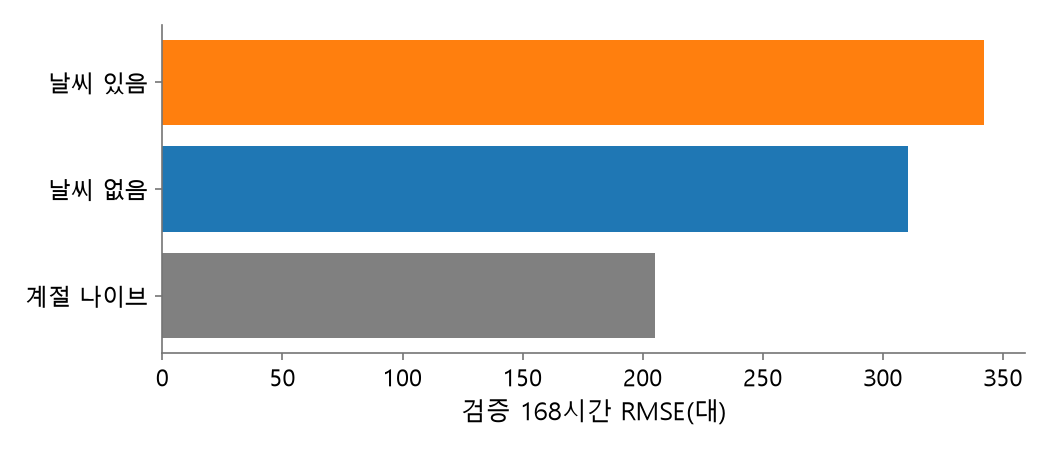

In [23]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
아래 출력물 나오도록 코드 작성해줘
1. 날씨를 더한 검증 168시간 RMSE: 단위 '대', 소수 둘째자리, REGS 두 열을 add_regressor로 ㄷ해 다시 적합
2. 기온 계수: 단위 '대/도', 소수 둘째자리, 기온이 1도 오를 때 수요가 몇 대 바뀌는지를 원래 단위로 읽은 값
3. 판단 한 행: 검중 구간에 날씨 열을 더할지와 운영에서 두 열의 미래 값을 어디에 채울지
4. 그래프
가로막대 3개
가로: '검증 168시간 RMSE(대)'
막대 이름: '계절 나이브', '날씨 없음', '날씨 있음'
"""
# --- 여기부터 AI 코드 ---
from prophet.utilities import regressor_coefficients

m2 = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
             holidays=holidays_one, interval_width=0.8, uncertainty_samples=1000)
for col in REGS:
    m2.add_regressor(col)

train_df2 = pd.DataFrame({"ds": train.index, "y": train["demand"].values})
for col in REGS:
    train_df2[col] = train[col].values
m2.fit(train_df2)

future2 = pd.DataFrame({"ds": valid.index})
for col in REGS:
    future2[col] = valid[col].values   # 검증 구간의 실측 날씨를 대입

np.random.seed(SEED)
fcst2 = m2.predict(future2)

WEATHER_RMSE = rmse(valid["demand"].values, fcst2["yhat"].values)
print(f"날씨를 더한 검증 168시간 RMSE = {WEATHER_RMSE:.2f} 대")

coefs = regressor_coefficients(m2)
temp_coef = coefs.loc[coefs["regressor"] == "temp", "coef"].values[0]
print(f"기온 계수 = {temp_coef:.2f} 대/도")

if WEATHER_RMSE < BASE_RMSE:
    print("판단: 이번 검증 구간은 날씨를 더해 RMSE가 줄었다 — 운영에서는 기상청 예보값으로 미래 기온·강수를 채운다")
else:
    print("판단: 이번 검증 구간은 날씨를 더해도 RMSE가 줄지 않았다 — 운영에서는 기상청 예보값으로 채우되 효과를 재검증한다")

fig, ax = plt.subplots(figsize=(7, 3))
names = ["계절 나이브", "날씨 없음", "날씨 있음"]
values = [SNAIVE_RMSE, BASE_RMSE, WEATHER_RMSE]
ax.barh(names, values, color=["gray", "tab:blue", "tab:orange"])
ax.set_xlabel("검증 168시간 RMSE(대)")
plt.show()


예측 원점 5개 평균 RMSE: Prophet 기본 구성 약 381대, 계절 나이브 168 363.55대. 11월 9일 한 주에서는 Prophet 이 작았지만 평균은 베이스라인이 작습니다
▸
일 수요 추세의 변화량이 큰 변화점은 연간 계절성을 포함하면 0곳, 제외하면 7곳이라 개수에는 모형에 포함한 성분을 함께 적습니다
▸
80% 예측구간은 11월 17～23일 168시간의 약 90% 를 담았고, 벗어난 시각은 위아래 양쪽에 있었습니다
▸
기온·강수를 더하면 실측 날씨를 대입한 사후 예측에서도 검증 RMSE 가 약 310대에서 약 340대로 커졌습니다
▸
할 일: 운영 예측은 df["demand"].shift(168) 로 냅니다. Prophet 구간을 함께 보고할 때는 m.interval_width 로 읽은 명목 포함률과 실제 포함률을 함께 적고, 날씨 열은 이번 검증 구간에 더하지 않습니다